In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
games_df       = pd.read_csv("data/data_sources_bronze/bgg_dataset_20260527.csv")
marketplace_df = pd.read_csv("data/data_sources_bronze/bgg_marketplace_20260527.csv")
awards_df      = pd.read_csv("data/data_sources_bronze/awards_dataset_20260516.csv")

In [3]:
awards_df = awards_df.drop(columns=["Unnamed: 0"], errors="ignore")
awards_df.head()

,year,award,category,game_name
0,2025,American Tabletop Awards,Early Gamers,Captain Flip
1,2024,American Tabletop Awards,Early Gamers,Blob Party
2,2023,American Tabletop Awards,Early Gamers,boop.
3,2022,American Tabletop Awards,Early Gamers,Happy City
4,2021,American Tabletop Awards,Early Gamers,Abandon All Artichokes


In [4]:
awards_summary = (
    awards_df
    .groupby("game_name")
    .agg(
        num_awards       = ("award",     "count"),
        awards_list      = ("award",     lambda x: " | ".join(sorted(set(x)))),
        first_award_year = ("year",      "min"),
        last_award_year  = ("year",      "max"),
    )
    .reset_index()
)
awards_summary.head()

,game_name,num_awards,awards_list,first_award_year,last_award_year
0,10 Days in Africa/USA,1,Mensa Select,2004,2004
1,25 Words or Less,1,Games magazine,1997,1997
2,3 Stones,1,Mensa Select,2000,2000
3,6 nimmt!,2,Deutscher Spiele Preis | Mensa Select,1994,1996
4,7 Wonders,2,Deutscher Spiele Preis | Spiel des Jahre,2011,2011


In [5]:
games_df["name_clean"]       = games_df["name"].str.lower().str.strip()
awards_summary["name_clean"] = awards_summary["game_name"].str.lower().str.strip()

In [6]:
games_with_awards = games_df.merge(
    awards_summary[["name_clean", "num_awards", "awards_list", "first_award_year"]],
    on="name_clean",
    how="inner"
)
games_with_awards["first_award_year"] = pd.to_numeric(games_with_awards["first_award_year"], errors="coerce")
games_with_awards.head()

,id,name,year,min_players,max_players,min_playtime,max_playtime,min_age,complexity,avg_rating,...,categories,mechanics,designers,publishers,families,num_logged,name_clean,num_awards,awards_list,first_award_year
0,342942,Ark Nova,2021,1,4,90,150,14,3.7967,8.54046,...,"Animals, Card Game, Environmental","Contracts, End Game Bonuses, Events, Grid Cove...",Mathias Wigge,"Feuerland Spiele, Capstone Games, CMON Global ...","Animals: Okapi, Components: Hexagonal Tiles, C...",NaN,ark nova,3,Deutscher Spiele Preis | Golden Geek Award (20...,2021
1,161936,Pandemic Legacy: Season 1,2015,2,4,60,60,13,2.8279,8.50231,...,"Environmental, Medical","Action Points, Cooperative Game, Hand Manageme...","Rob Daviau, Matt Leacock","Z-Man Games, Asterion Press, Devir, Filosofia ...","Components: Map (Global Scale), Components: Mu...",NaN,pandemic legacy: season 1,1,Golden Geek Award (Till 2019),2015
2,174430,Gloomhaven,2017,1,4,60,120,14,3.9192,8.53879,...,"Adventure, Exploration, Fantasy, Fighting, Min...","Action Queue, Action Retrieval, Campaign / Bat...",Isaac Childres,"Cephalofair Games, Albi, Albi Polska, Arclight...","Category: Dungeon Crawler, Components: Map (Ci...",NaN,gloomhaven,1,Golden Geek Award (Till 2019),2017
3,167791,Terraforming Mars,2016,1,5,120,120,12,3.2718,8.33611,...,"Civilization, Economic, Environmental, Industr...","Closed Drafting, Contracts, End Game Bonuses, ...",Jacob Fryxelius,"FryxGames, Arclight Games, Brädspel.se, Fantas...","Category: DIZED Tutorial, Components: Map (Glo...",NaN,terraforming mars,3,Board Game Quest Awards | Deutscher Spiele Pre...,2016
4,162886,Spirit Island,2017,1,4,90,120,13,4.0730,8.34003,...,"Environmental, Fantasy, Mythology, Territory B...","Action Retrieval, Area Majority / Influence, A...",R. Eric Reuss,"Greater Than Games, LLC, 999 Games, Ace Studio...","Category: DIZED Tutorial, Components: Control ...",NaN,spirit island,1,Le Diamant d'Or,2018


In [7]:
marketplace_df["date"] = pd.to_datetime(marketplace_df["date"], format="mixed", errors="coerce").dt.tz_localize(None)

In [8]:
award_market = marketplace_df.merge(
    games_with_awards[["id", "name", "first_award_year",
                        "num_awards", "avg_rating", "awards_list"]],
    on="id",
    how="inner"
)
award_market.head()

,id,name_x,date,price_orig,currency,price_usd,condition,year_month,name_y,first_award_year,num_awards,avg_rating,awards_list
0,342942,Ark Nova,2021-12-18 09:29:56,61.0,EUR,65.88,new,2021-12,Ark Nova,2021,3,8.54046,Deutscher Spiele Preis | Golden Geek Award (20...
1,342942,Ark Nova,2022-03-26 16:28:58,78.0,EUR,84.24,new,2022-03,Ark Nova,2021,3,8.54046,Deutscher Spiele Preis | Golden Geek Award (20...
2,342942,Ark Nova,2022-04-20 16:03:48,90.0,EUR,97.20,new,2022-04,Ark Nova,2021,3,8.54046,Deutscher Spiele Preis | Golden Geek Award (20...
3,342942,Ark Nova,2022-05-01 08:46:24,70.0,EUR,75.60,new,2022-05,Ark Nova,2021,3,8.54046,Deutscher Spiele Preis | Golden Geek Award (20...
4,342942,Ark Nova,2022-05-14 18:40:57,52.0,USD,52.00,new,2022-05,Ark Nova,2021,3,8.54046,Deutscher Spiele Preis | Golden Geek Award (20...


In [9]:
award_market.shape

(11629, 13)

In [10]:
top3 = (
    award_market.groupby("name_x")["price_usd"]
    .count()
    .nlargest(3)
    .index.tolist()
)
print(f"Top 3 games selected: {top3}")

Top 3 games selected: ['Gloomhaven', 'Small World', 'Scythe']


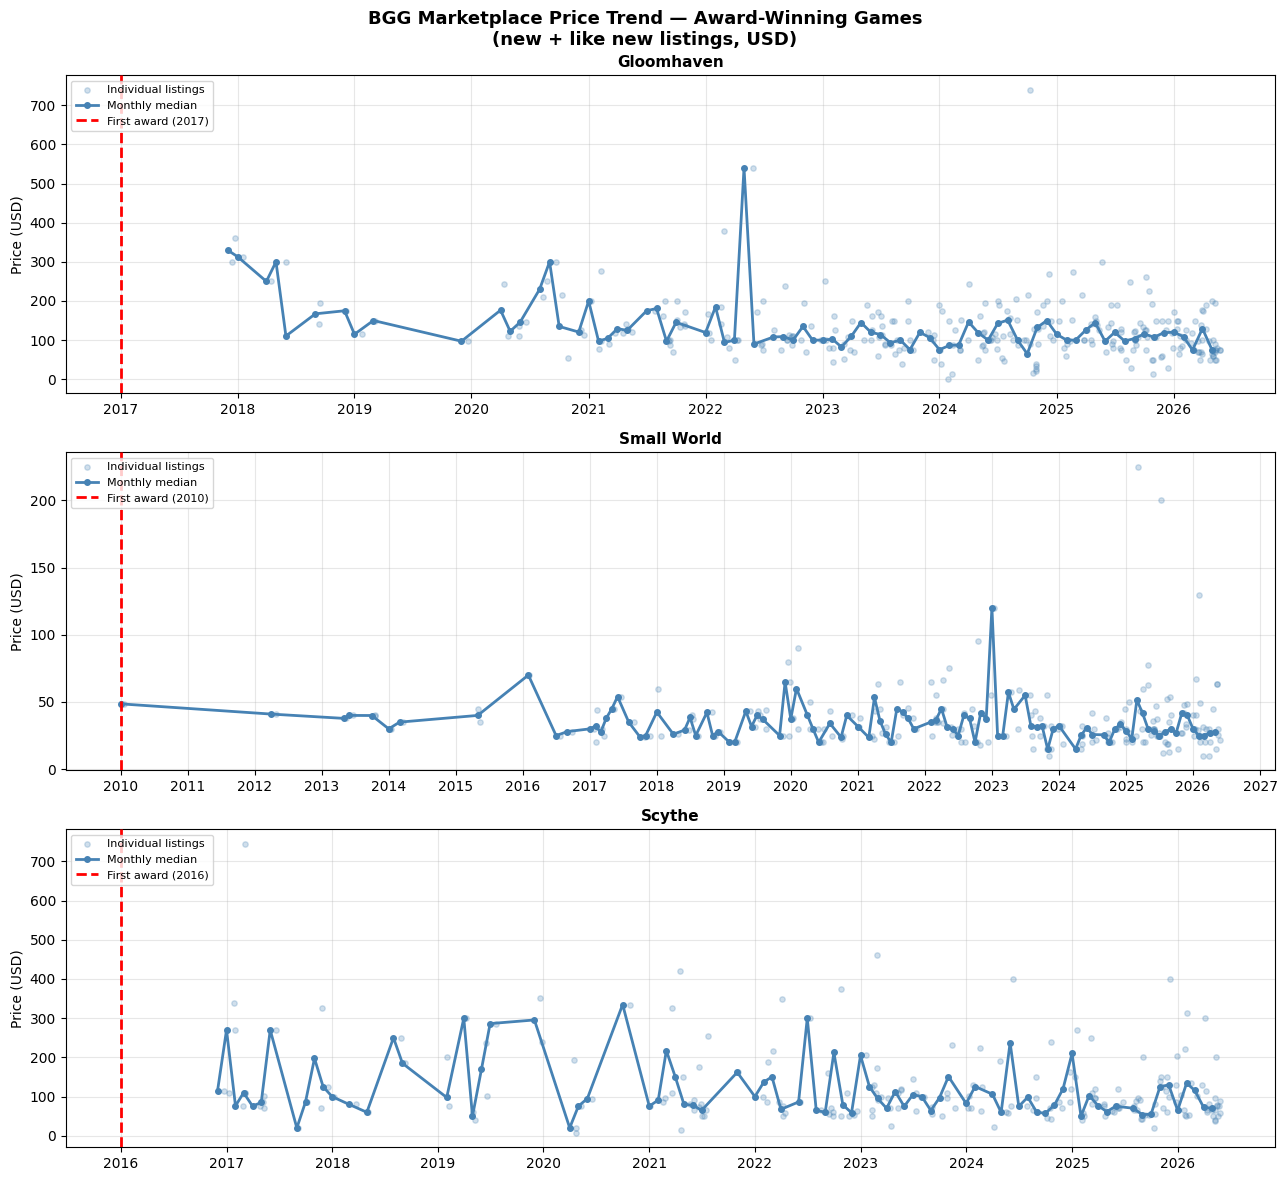

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=False)
fig.suptitle("BGG Marketplace Price Trend — Award-Winning Games\n"
             "(new + like new listings, USD)",
             fontsize=13, fontweight="bold")

for ax, game_name in zip(axes, top3):
    g          = award_market[award_market["name_x"] == game_name].sort_values("date")
    award_year = int(g["first_award_year"].iloc[0])
    award_date = pd.Timestamp(f"{award_year}-01-01")

    # Monthly median
    monthly = (
        g.groupby(g["date"].dt.to_period("M"))["price_usd"]
        .median()
        .reset_index()
    )
    monthly["date_ts"] = monthly["date"].dt.to_timestamp()

    # Raw scatter
    ax.scatter(g["date"], g["price_usd"],
               alpha=0.25, s=15, color="steelblue", zorder=2,
               label="Individual listings")

    # Monthly median line
    ax.plot(monthly["date_ts"], monthly["price_usd"],
            color="steelblue", linewidth=2,
            marker="o", markersize=4, label="Monthly median", zorder=3)

    # Red award year line
    ax.axvline(award_date, color="red", linewidth=2,
               linestyle="--", zorder=4,
               label=f"First award ({award_year})")

    ax.set_title(game_name, fontweight="bold", fontsize=11)
    ax.set_ylabel("Price (USD)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

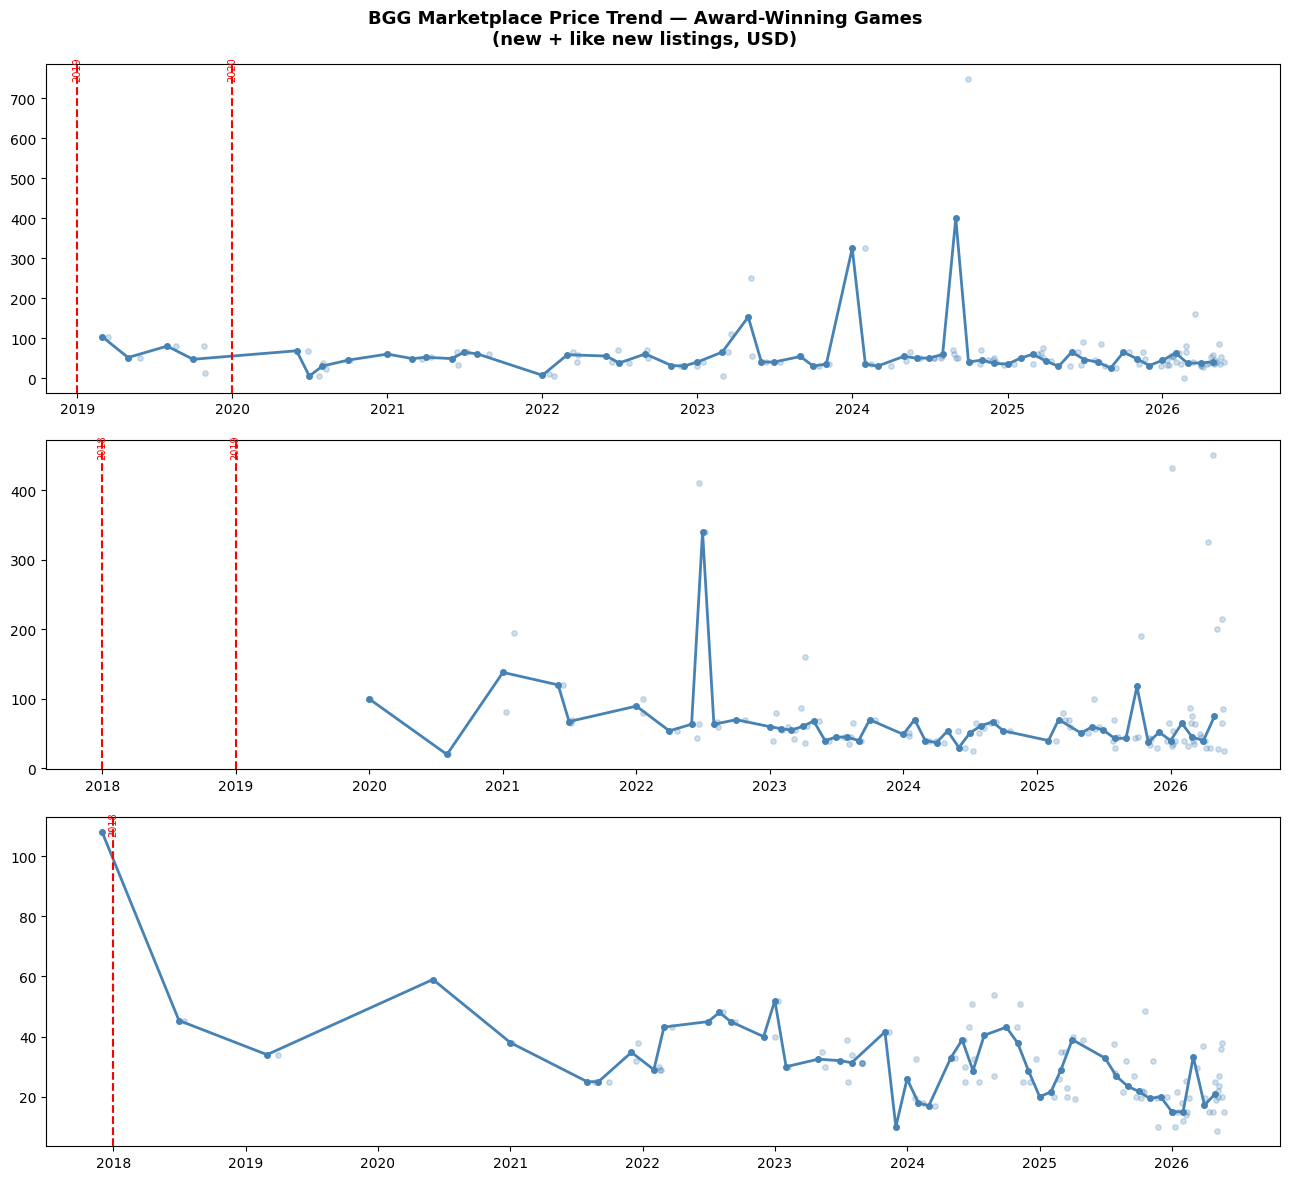

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=False)
fig.suptitle("BGG Marketplace Price Trend — Award-Winning Games\n"
             "(new + like new listings, USD)",
             fontsize=13, fontweight="bold")

for ax, game_name in zip(axes, ["Wingspan", "Root", "Azul"]):
    g = award_market[award_market["name_x"] == game_name].sort_values("date")

    # Get ALL award years for this game from the raw awards_df
    all_award_years = (
        awards_df[awards_df["game_name"].str.lower().str.strip()
                  == game_name.lower().strip()]["year"]
        .dropna()
        .unique()
        .tolist()
    )

    # Monthly median
    monthly = (
        g.groupby(g["date"].dt.to_period("M"))["price_usd"]
        .median()
        .reset_index()
    )
    monthly["date_ts"] = monthly["date"].dt.to_timestamp()

    # Raw scatter
    ax.scatter(g["date"], g["price_usd"],
               alpha=0.25, s=15, color="steelblue", zorder=2,
               label="Individual listings")

    # Monthly median line
    ax.plot(monthly["date_ts"], monthly["price_usd"],
            color="steelblue", linewidth=2,
            marker="o", markersize=4, label="Monthly median", zorder=3)

    # Red award year line
    for i, yr in enumerate(sorted(all_award_years)):
        award_date = pd.Timestamp(f"{int(yr)}-01-01")
        ax.axvline(
            award_date,
            color="red",
            linewidth=1.5,
            linestyle="--",
            zorder=4,
            # Only add label on first line to avoid duplicate legend entries
            label="Award year" if i == 0 else None
        )
        # Annotate each line with the award year
        ax.text(
            award_date,
            ax.get_ylim()[1] * 0.95,
            str(int(yr)),
            color="red",
            fontsize=7,
            ha="center",
            rotation=90
        )

plt.tight_layout()
plt.show()

In [13]:
awards_summary.sort_values(["num_awards"], ascending=False).head()

,game_name,num_awards,awards_list,first_award_year,last_award_year,name_clean
382,Wingspan,7,American Tabletop Awards | Board Game Quest Aw...,2019,2020,wingspan
275,Root,6,American Tabletop Awards | Board Game Quest Aw...,2018,2019,root
23,Azul,4,As d'Or / Golden Ace | Deutscher Spiele Preis ...,2018,2018,azul
8,Agricola,4,Deutscher Spiele Preis | Golden Geek Award (Ti...,2008,2008,agricola
88,Dominion,4,Deutscher Spiele Preis | Golden Geek Award (Ti...,2009,2009,dominion


In [14]:
import datetime

today      = pd.Timestamp.today().normalize()
cutoff     = today - pd.Timedelta(days=365)

recent = marketplace_df[marketplace_df["date"] >= cutoff].copy()

listing_counts = (
    recent
    .groupby("name")
    .agg(
        listings_last_30d = ("price_usd", "count"),
        avg_price_usd     = ("price_usd", "mean"),
        median_price_usd  = ("price_usd", "median"),
        min_price_usd     = ("price_usd", "min"),
        max_price_usd     = ("price_usd", "max"),
    )
    .reset_index()
    .sort_values("listings_last_30d", ascending=False)
    .round(2)
)

print(listing_counts.head(10).to_string(index=False))

                                            name  listings_last_30d  avg_price_usd  median_price_usd  min_price_usd  max_price_usd
                                        Pandemic                 97          30.25             20.00           8.00         151.20
                                      Gloomhaven                 88         107.86            100.00          13.99         260.00
                               The 7th Continent                 77          97.38             76.20           1.00         275.00
                                  7 Wonders Duel                 62          25.27             21.60           5.00          80.00
                  Endless Winter: Paleoamericans                 60          78.99             74.76          25.00         270.00
Robinson Crusoe: Adventures on the Cursed Island                 59          47.79             35.00          16.20         239.00
                                          Scythe                 58         101.48 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b3536b60-e481-4f67-b46c-1c4de87b554b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>